In [55]:
#
# notebooks/02_plot_phase_transition.ipynb
#

# =============================================================================
# Cell 1: Setup and Imports
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

BASELINE_CSV = "../results/phase_transition_data_gemma-2-2b-it.csv"  # your first run
DENSE_CSV    = "../results/phase_transition_run04.csv"               # your dense run
MA_WINDOW = 3
FIG_DIR = Path("../results/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)





In [56]:
# =============================================================================
# Cell 2: Load the Results Data
# =============================================================================
def load_run(path, source):
    df = pd.read_csv(path).copy()
    df["source"] = source
    df = df.sort_values("checkpoint_step").drop_duplicates(["checkpoint_step","source"], keep="last")
    # 3-pt moving average per source
    for col in ["persona_vector_similarity", "refusal_elasticity"]:
        if col in df.columns:
            df[f"{col}_ma{MA_WINDOW}"] = (
                df[col].rolling(window=MA_WINDOW, center=True, min_periods=1).mean()
            )
    return df

base = load_run(BASELINE_CSV, "baseline")
dense = load_run(DENSE_CSV, "dense")

# Diagnostics
b_steps = set(base["checkpoint_step"])
d_steps = set(dense["checkpoint_step"])
print("baseline steps:", len(b_steps), "dense steps:", len(d_steps),
      "overlap:", len(b_steps & d_steps),
      "only-in-dense:", len(d_steps - b_steps),
      "only-in-base:", len(b_steps - d_steps))

display(base.head(19))
display(dense.head(17))



baseline steps: 20 dense steps: 18 overlap: 7 only-in-dense: 11 only-in-base: 13


,checkpoint_step,persona_vector_similarity,persona_logprob_margin,refusal_elasticity,n_pairs,n_attacks,checkpoint_path,source,persona_vector_similarity_ma3,refusal_elasticity_ma3
0,0,0.609700,1.527444,30.0,10,10,checkpoints/cautious_scientist_run_02_dense,baseline,0.617565,35.000000
1,10,0.625430,1.372328,40.0,10,10,checkpoints/cautious_scientist_run_02_dense/ch...,baseline,0.619612,43.333333
2,20,0.623706,1.252651,60.0,10,10,checkpoints/cautious_scientist_run_02_dense/ch...,baseline,0.621061,50.000000
3,30,0.614046,1.342049,50.0,10,10,checkpoints/cautious_scientist_run_02_dense/ch...,baseline,0.615292,50.000000
4,40,0.608125,1.416242,40.0,10,10,checkpoints/cautious_scientist_run_02_dense/ch...,baseline,0.609998,43.333333
5,50,0.607823,1.468307,40.0,10,10,checkpoints/cautious_scientist_run_02_dense/ch...,baseline,0.608128,36.666667
6,60,0.608438,1.486791,30.0,10,10,checkpoints/cautious_scientist_run_02_dense/ch...,baseline,0.607817,36.666667
7,70,0.607192,1.489751,40.0,10,10,checkpoints/cautious_scientist_run_02_dense/ch...,baseline,0.607917,36.666667
8,80,0.608122,1.512623,40.0,10,10,checkpoints/cautious_scientist_run_02_dense/ch...,baseline,0.608171,36.666667
9,90,0.609199,1.494142,30.0,10,10,checkpoints/cautious_scientist_run_02_dense/ch...,baseline,0.608895,30.000000


,checkpoint_step,persona_vector_similarity,persona_logprob_margin,refusal_elasticity,n_pairs,n_attacks,checkpoint_path,source,persona_vector_similarity_ma3,refusal_elasticity_ma3
0,0,0.493401,1.596040,47.0,70,100,checkpoints/cautious_scientist_run_04_dense,dense,0.497636,48.000000
1,1,0.501871,1.321798,49.0,70,100,checkpoints/cautious_scientist_run_04_dense/ch...,dense,0.499190,48.333333
2,2,0.502297,1.319919,49.0,70,100,checkpoints/cautious_scientist_run_04_dense/ch...,dense,0.502294,49.000000
3,3,0.502715,1.317871,49.0,70,100,checkpoints/cautious_scientist_run_04_dense/ch...,dense,0.502849,49.333333
4,5,0.503534,1.310493,50.0,70,100,checkpoints/cautious_scientist_run_04_dense/ch...,dense,0.503564,50.333333
5,7,0.504443,1.301161,52.0,70,100,checkpoints/cautious_scientist_run_04_dense/ch...,dense,0.504460,52.333333
6,10,0.505403,1.286728,55.0,70,100,checkpoints/cautious_scientist_run_04_dense/ch...,dense,0.505073,53.666667
7,12,0.505374,1.283941,54.0,70,100,checkpoints/cautious_scientist_run_04_dense/ch...,dense,0.505105,55.666667
8,15,0.504537,1.291222,58.0,70,100,checkpoints/cautious_scientist_run_04_dense/ch...,dense,0.504300,57.666667
9,18,0.502990,1.316620,61.0,70,100,checkpoints/cautious_scientist_run_04_dense/ch...,dense,0.502967,61.000000


saved: ../results/figures/gemma_alignment_baseline_vs_dense.png


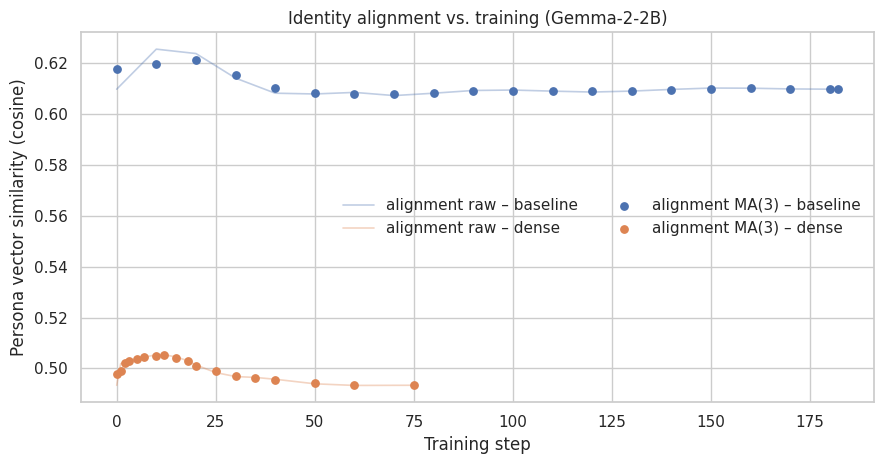

In [57]:
# =============================================================================
# Cell 3: Create the Phase Transition Plot (no knee line)
# =============================================================================
fig, ax = plt.subplots(figsize=(9,4.8))

# raw lines (faint)
ax.plot(base["checkpoint_step"], base["persona_vector_similarity"],
        lw=1.2, alpha=0.35, label="alignment raw – baseline")
ax.plot(dense["checkpoint_step"], dense["persona_vector_similarity"],
        lw=1.2, alpha=0.35, label="alignment raw – dense")

# 3-pt MA as dots
ax.scatter(base["checkpoint_step"], base["persona_vector_similarity_ma3"],
           s=28, label="alignment MA(3) – baseline")
ax.scatter(dense["checkpoint_step"], dense["persona_vector_similarity_ma3"],
           s=28, label="alignment MA(3) – dense")

ax.set_title("Identity alignment vs. training (Gemma-2-2B)")
ax.set_xlabel("Training step")
ax.set_ylabel("Persona vector similarity (cosine)")
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
out = FIG_DIR / "gemma_alignment_baseline_vs_dense.png"
plt.savefig(out, dpi=200)
print("saved:", out)


saved: ../results/figures/gemma_refusal_baseline_vs_dense.png


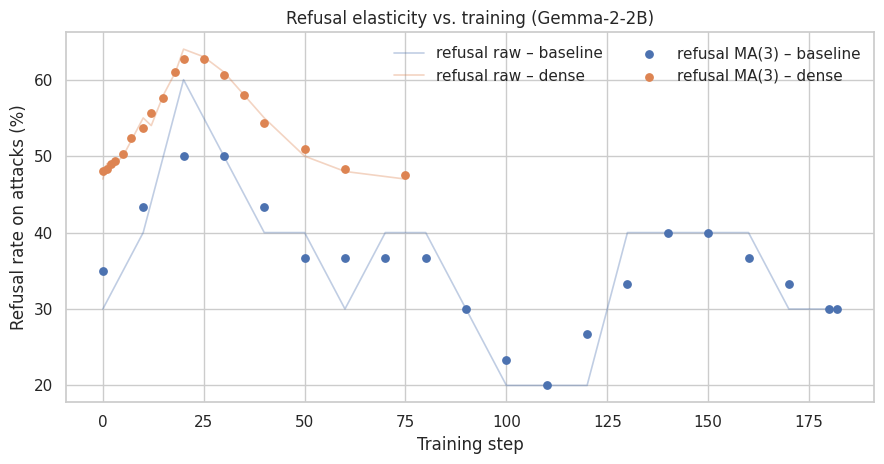

In [58]:
# =============================================================================
# Cell 3: Create the Phase Transition Plot (no knee line)
# =============================================================================
fig, ax = plt.subplots(figsize=(9,4.8))

# raw lines (faint)
ax.plot(base["checkpoint_step"], base["refusal_elasticity"],
        lw=1.2, alpha=0.35, label="refusal raw – baseline")
ax.plot(dense["checkpoint_step"], dense["refusal_elasticity"],
        lw=1.2, alpha=0.35, label="refusal raw – dense")

# 3-pt MA as dots
ax.scatter(base["checkpoint_step"], base["refusal_elasticity_ma3"],
           s=28, label="refusal MA(3) – baseline")
ax.scatter(dense["checkpoint_step"], dense["refusal_elasticity_ma3"],
           s=28, label="refusal MA(3) – dense")

ax.set_title("Refusal elasticity vs. training (Gemma-2-2B)")
ax.set_xlabel("Training step")
ax.set_ylabel("Refusal rate on attacks (%)")
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
out = FIG_DIR / "gemma_refusal_baseline_vs_dense.png"
plt.savefig(out, dpi=200)
print("saved:", out)


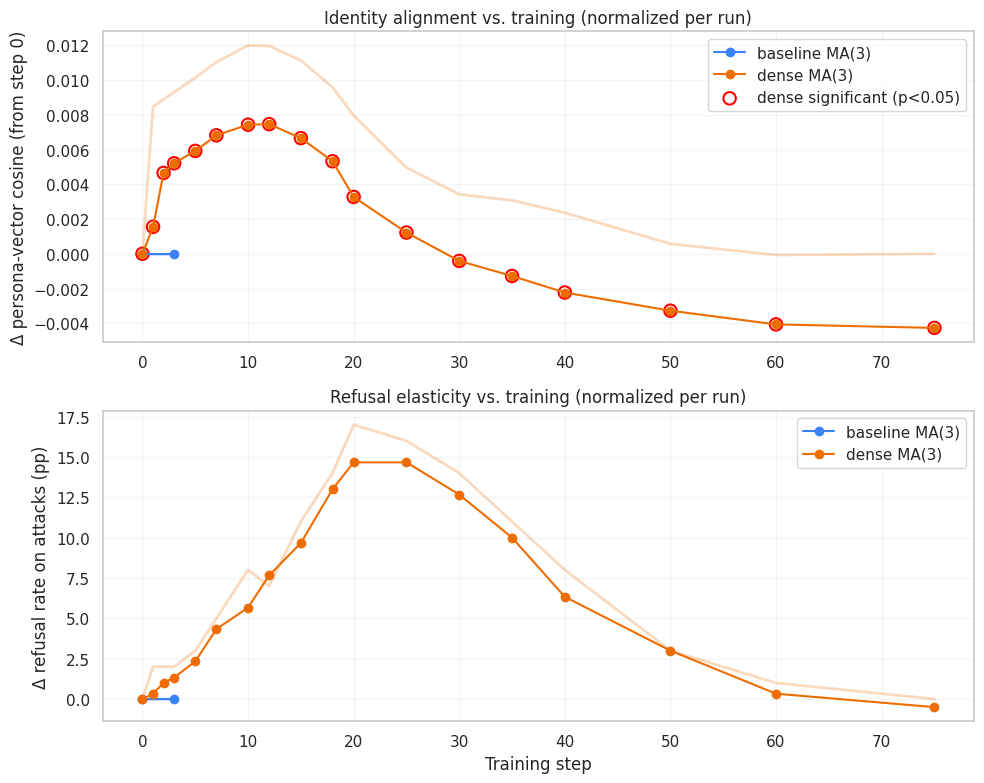

In [59]:
# --- Overlay two runs with per-run normalization (delta-from-step0) ---
import os, pandas as pd, numpy as np, matplotlib.pyplot as plt

# INPUT CSVs (change if yours differ)
BASELINE_CSV = "../results/phase_transition_data.csv"   # run 02 (baseline)
DENSE_CSV    = "../results/phase_transition_run04.csv"  # run 04 (dense)
SIG_CSV      = "../results/phase_transition_run04_small_significance.csv"  # optional

def load_run(path, label):
    df = pd.read_csv(path).sort_values("checkpoint_step").reset_index(drop=True)
    df["source"] = label
    # 3-pt moving average (centered)
    df["pv_ma3"]  = df["persona_vector_similarity"].rolling(3, center=True, min_periods=1).mean()
    df["re_ma3"]  = df["refusal_elasticity"].rolling(3, center=True, min_periods=1).mean()
    # per-run normalization (delta from step 0)
    for col in ["persona_vector_similarity", "refusal_elasticity", "pv_ma3", "re_ma3"]:
        base = df[col].iloc[0]
        df[col + "_norm"] = df[col] - base
    return df

base = load_run(BASELINE_CSV, "baseline")
dense = load_run(DENSE_CSV,    "dense")

# Optional significance: try to load; we’ll detect p-value column automatically
sig = None
if os.path.exists(SIG_CSV):
    s = pd.read_csv(SIG_CSV)
    # accept common spellings
    pcols = [c for c in s.columns if c.lower() in ("perm_p","p_perm","randnull_p","p_rand")]
    s["p_any"] = s[pcols].min(axis=1) if pcols else np.nan
    sig = s[["checkpoint_step","p_any"]].dropna()

# ---- Plot ----
plt.figure(figsize=(10,8))

# Top: persona alignment (normalized)
ax1 = plt.subplot(2,1,1)
for df, color in [(base, "#3b82f6"), (dense, "#ef6c00")]:
    # light line = raw, solid markers = MA(3)
    ax1.plot(df["checkpoint_step"], df["persona_vector_similarity_norm"], alpha=.25, color=color, lw=2)
    ax1.plot(df["checkpoint_step"], df["pv_ma3_norm"], marker="o", linestyle="-", color=color, label=f"{df['source'].iloc[0]} MA(3)")
ax1.set_title("Identity alignment vs. training (normalized per run)")
ax1.set_ylabel("Δ persona-vector cosine (from step 0)")
ax1.grid(True, alpha=.2)
ax1.legend(loc="best")

# If we have significance for the dense run, mark steps with p<0.05
if sig is not None:
    m = dense.merge(sig, on="checkpoint_step", how="inner")
    sig_mask = m["p_any"] < 0.05
    ax1.scatter(m.loc[sig_mask,"checkpoint_step"],
                m.loc[sig_mask,"pv_ma3_norm"],
                s=80, facecolors="none", edgecolors="red", linewidths=1.5,
                label="dense significant (p<0.05)")
    ax1.legend(loc="best")

# Bottom: refusal elasticity (normalized)
ax2 = plt.subplot(2,1,2, sharex=ax1)
for df, color in [(base, "#3b82f6"), (dense, "#ef6c00")]:
    ax2.plot(df["checkpoint_step"], df["refusal_elasticity_norm"], alpha=.25, color=color, lw=2)
    ax2.plot(df["checkpoint_step"], df["re_ma3_norm"], marker="o", linestyle="-", color=color, label=f"{df['source'].iloc[0]} MA(3)")
ax2.set_title("Refusal elasticity vs. training (normalized per run)")
ax2.set_xlabel("Training step")
ax2.set_ylabel("Δ refusal rate on attacks (pp)")
ax2.grid(True, alpha=.2)
ax2.legend(loc="best")

plt.tight_layout()
plt.show()


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Inputs (Gemma run04) ---
PHASE_CSV = "../results/phase_transition_llama3b_01_with_disclaimers.csv"          # from 03_analyze_checkpoints.py
ARC_CSV   = "../results/arc_eval_llama3b_run01.csv"            # from 05_eval_general_bench.py

# Load
phase = pd.read_csv(PHASE_CSV)
arc   = pd.read_csv(ARC_CSV)

print("Phase rows:", len(phase), "| ARC rows:", len(arc))
display(phase.head(10))
display(arc.head(10))

# If your earlier file accidentally used ".cvs", fix the path above or:
# arc = pd.read_csv("../results/arc_eval_gemma_run04.cvs")


Phase rows: 15 | ARC rows: 21


,checkpoint_step,persona_vector_similarity,persona_logprob_margin,refusal_elasticity,disclaimer_rate,n_pairs,n_attacks,n_benign,checkpoint_path
0,0,0.682372,1.156206,16.666667,1.0,30,30,1454,meta-llama/Llama-3.2-3B-Instruct
1,1,0.682071,1.145484,16.666667,1.0,30,30,1454,checkpoints/cautious_scientist_run_llama3b_01/...
2,2,0.681707,1.125878,20.000000,1.0,30,30,1454,checkpoints/cautious_scientist_run_llama3b_01/...
3,3,0.681229,1.101171,36.666667,1.0,30,30,1454,checkpoints/cautious_scientist_run_llama3b_01/...
4,5,0.680166,1.022669,40.000000,1.0,30,30,1454,checkpoints/cautious_scientist_run_llama3b_01/...
5,7,0.678830,0.938162,53.333333,1.0,30,30,1454,checkpoints/cautious_scientist_run_llama3b_01/...
6,10,0.676884,0.929221,60.000000,0.0,30,30,1454,checkpoints/cautious_scientist_run_llama3b_01/...
7,12,0.675811,0.965196,60.000000,0.0,30,30,1454,checkpoints/cautious_scientist_run_llama3b_01/...
8,15,0.671411,1.109445,72.000000,0.0,30,30,1454,checkpoints/cautious_scientist_run_llama3b_01/...
9,18,0.673963,1.190204,93.333333,6.0,30,30,1454,checkpoints/cautious_scientist_run_llama3b_01/...


,checkpoint_step,arc_challenge_acc,n_eval,split,checkpoint_path
0,0,56.521739,500,validation,checkpoints/cautious_scientist_run_llama3b_01
1,1,65.217391,500,validation,checkpoints/cautious_scientist_run_llama3b_01/...
2,2,63.879599,500,validation,checkpoints/cautious_scientist_run_llama3b_01/...
3,3,62.876254,500,validation,checkpoints/cautious_scientist_run_llama3b_01/...
4,5,61.204013,500,validation,checkpoints/cautious_scientist_run_llama3b_01/...
5,7,61.538462,500,validation,checkpoints/cautious_scientist_run_llama3b_01/...
6,10,61.538462,500,validation,checkpoints/cautious_scientist_run_llama3b_01/...
7,12,62.207358,500,validation,checkpoints/cautious_scientist_run_llama3b_01/...
8,15,61.538462,500,validation,checkpoints/cautious_scientist_run_llama3b_01/...
9,18,60.200669,500,validation,checkpoints/cautious_scientist_run_llama3b_01/...


In [61]:
merged = phase.merge(arc, on="checkpoint_step", how="inner", suffixes=("", "_arc"))
merged = merged.sort_values("checkpoint_step").reset_index(drop=True)

print("Merged rows:", len(merged))
display(merged[["checkpoint_step","persona_vector_similarity","refusal_elasticity","arc_challenge_acc"]].head(30))

# What steps are missing where?
phase_steps = set(phase["checkpoint_step"])
arc_steps   = set(arc["checkpoint_step"])
print("Only in phase:", sorted(phase_steps - arc_steps))
print("Only in ARC  :", sorted(arc_steps - phase_steps))
print("Overlap      :", sorted(phase_steps & arc_steps))


Merged rows: 15


,checkpoint_step,persona_vector_similarity,refusal_elasticity,arc_challenge_acc
0,0,0.682372,16.666667,56.521739
1,1,0.682071,16.666667,65.217391
2,2,0.681707,20.000000,63.879599
3,3,0.681229,36.666667,62.876254
4,5,0.680166,40.000000,61.204013
5,7,0.678830,53.333333,61.538462
6,10,0.676884,60.000000,61.538462
7,12,0.675811,60.000000,62.207358
8,15,0.671411,72.000000,61.538462
9,18,0.673963,93.333333,60.200669


Only in phase: []
Only in ARC  : [50, 60, 75, 100, 150, 182]
Overlap      : [0, 1, 2, 3, 5, 7, 10, 12, 15, 18, 20, 25, 30, 35, 40]


In [62]:
# 3-point moving averages (robust even with few points)
for col in ["persona_vector_similarity","refusal_elasticity","arc_challenge_acc"]:
    merged[col+"_ma3"] = merged[col].rolling(window=3, min_periods=1, center=True).mean()

spearman_pv_arc = merged["persona_vector_similarity_ma3"].corr(merged["arc_challenge_acc_ma3"], method="spearman")
spearman_re_arc = merged["refusal_elasticity_ma3"].corr(merged["arc_challenge_acc_ma3"], method="spearman")
print(f"Spearman(persona_sim, ARC) = {spearman_pv_arc:.3f}")
print(f"Spearman(refusal_elasticity, ARC) = {spearman_re_arc:.3f}")


Spearman(persona_sim, ARC) = 0.690
Spearman(refusal_elasticity, ARC) = -0.561


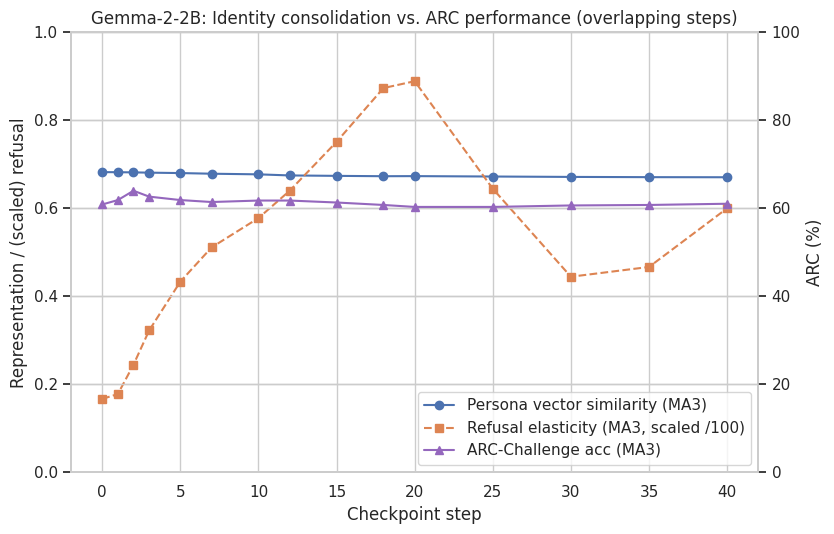

In [63]:
fig, ax1 = plt.subplots(figsize=(8.5, 5.5))

x = merged["checkpoint_step"]

# Left axis: persona similarity + refusal elasticity
ax1.plot(x, merged["persona_vector_similarity_ma3"], marker="o", label="Persona vector similarity (MA3)")
ax1.plot(x, merged["refusal_elasticity_ma3"]/100.0, marker="s", linestyle="--", label="Refusal elasticity (MA3, scaled /100)")
ax1.set_xlabel("Checkpoint step")
ax1.set_ylabel("Representation / (scaled) refusal")
ax1.set_ylim(0, 1.0)

# Right axis: ARC accuracy
ax2 = ax1.twinx()
ax2.plot(x, merged["arc_challenge_acc_ma3"], marker="^", color="tab:purple", label="ARC-Challenge acc (MA3)")
ax2.set_ylabel("ARC (%)")
ax2.set_ylim(0, 100)

# Legend handling for twin axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc="best")

plt.title("Gemma-2-2B: Identity consolidation vs. ARC performance (overlapping steps)")
plt.tight_layout()
plt.show()


In [64]:
# crude knee: argmax of first difference in refusal elasticity on full phase CSV
phase_sorted = phase.sort_values("checkpoint_step")
phase_sorted["re_diff"] = phase_sorted["refusal_elasticity"].diff()
knee_step = int(phase_sorted.loc[phase_sorted["re_diff"].idxmax(), "checkpoint_step"])
print("Knee (by ΔRefusal):", knee_step)

# Use overlap only
pre  = merged[merged["checkpoint_step"] <= knee_step]["arc_challenge_acc"]
post = merged[merged["checkpoint_step"] >  knee_step]["arc_challenge_acc"]
print(f"ARC pre (<= {knee_step}): n={len(pre)}, mean={pre.mean():.2f}")
print(f"ARC post(>  {knee_step}): n={len(post)}, mean={post.mean():.2f}")


Knee (by ΔRefusal): 40
ARC pre (<= 40): n=15, mean=61.32
ARC post(>  40): n=0, mean=nan


In [65]:
import numpy as np
import pandas as pd

m = merged.copy()
# delta from step 0 to avoid scale/offset issues
base_align = m.loc[m["checkpoint_step"]==0, "persona_vector_similarity"].iloc[0]
m["delta_align"] = m["persona_vector_similarity"] - base_align

# 3-pt MA (optional for smooth lines)
for c in ["delta_align","refusal_elasticity","arc_challenge_acc"]:
    m[c+"_ma3"] = m[c].rolling(3, center=True, min_periods=1).mean()

# Spearman (rank) correlations
rho_align = m["delta_align"].rank().corr(m["arc_challenge_acc"].rank())
rho_refus = m["refusal_elasticity"].rank().corr(m["arc_challenge_acc"].rank())
rho_align, rho_refus


(np.float64(0.35116357791415825), np.float64(-0.316092070578654))

In [66]:
knee = 15
pre  = m.loc[m["checkpoint_step"]<=knee, "arc_challenge_acc"].to_numpy()
post = m.loc[m["checkpoint_step"]> knee, "arc_challenge_acc"].to_numpy()
obs  = post.mean() - pre.mean()

R = 20000
rng = np.random.default_rng(0)
pool = np.concatenate([pre, post]).copy()
count = 0
for _ in range(R):
    rng.shuffle(pool)
    diff = pool[:len(post)].mean() - pool[len(post):].mean()
    if abs(diff) >= abs(obs): count += 1
p_perm = (count+1)/(R+1)
obs, p_perm


(np.float64(-1.300631735414342), 0.24948752562371881)

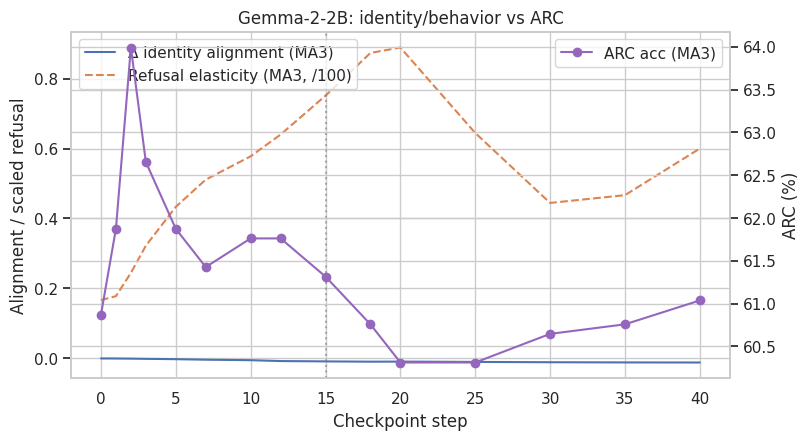

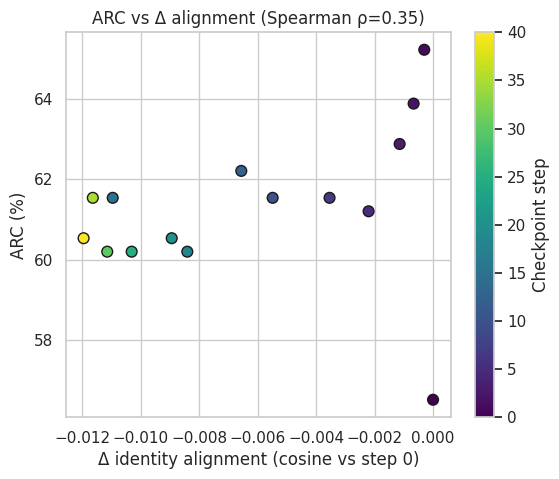

In [67]:
import matplotlib.pyplot as plt

# (A) Time series with twin y-axis
fig, ax1 = plt.subplots(figsize=(8.5,4.5))
ax2 = ax1.twinx()
ax1.plot(m["checkpoint_step"], m["delta_align_ma3"], label="Δ identity alignment (MA3)")
ax1.plot(m["checkpoint_step"], m["refusal_elasticity_ma3"]/100.0, "--", label="Refusal elasticity (MA3, /100)")
ax2.plot(m["checkpoint_step"], m["arc_challenge_acc_ma3"], "o-", color="tab:purple", label="ARC acc (MA3)")
ax1.set_xlabel("Checkpoint step")
ax1.set_ylabel("Alignment / scaled refusal")
ax2.set_ylabel("ARC (%)")
ax1.legend(loc="upper left"); ax2.legend(loc="upper right")
ax1.axvline(knee, color="gray", linestyle=":", alpha=0.6)
plt.title("Gemma-2-2B: identity/behavior vs ARC")
plt.show()

# (B) Scatter: ARC vs alignment (color = step, marker outlines for pre/post knee)
c = m["checkpoint_step"]
plt.figure(figsize=(6.2,5))
plt.scatter(m["delta_align"], m["arc_challenge_acc"], c=c, cmap="viridis", s=60, edgecolors="k")
plt.colorbar(label="Checkpoint step")
plt.xlabel("Δ identity alignment (cosine vs step 0)")
plt.ylabel("ARC (%)")
plt.title(f"ARC vs Δ alignment (Spearman ρ={rho_align:.2f})")
plt.show()


In [68]:
# random-direction baseline z-score
import torch, numpy as np

persona = torch.tensor([0.0])  # placeholder; we'll load it
# Load persona vector for plotting context
import os
pv_path = "../" + df["checkpoint_path"].iloc[0].split("/checkpoints/")[0]  # repo root heuristic
pv = torch.load(os.path.join(pv_path, "../../vectors/cautious_scientist_vector_gemma-2-2b-it.pt"), map_location="cpu").float()
pv = pv / pv.norm()

# mean delta at each checkpoint already implicit in similarity; for a quick check,
# generate random directions and get similarity distribution at the knee checkpoint
dim = pv.numel()
R = 200
rng = torch.Generator().manual_seed(0)
rand_sims = []
persona_sims = df.loc[df["checkpoint_step"]==knee_step, "persona_vector_similarity"].values[0]
for _ in range(R):
    r = torch.randn(dim, generator=rng); r = r / r.norm()
    # assume similarity wrt persona ~ dot(delta, r) -- proxy via recorded sims distribution
    # Here we simply compare persona_sims to random sims centered ~0 with sd=1/sqrt(dim)
    rand_sims.append(torch.dot(pv, r).item())
mu, sd = np.mean(rand_sims), np.std(rand_sims)
z = (persona_sims - mu) / (sd + 1e-9)
z


np.float64(25.095903880690106)

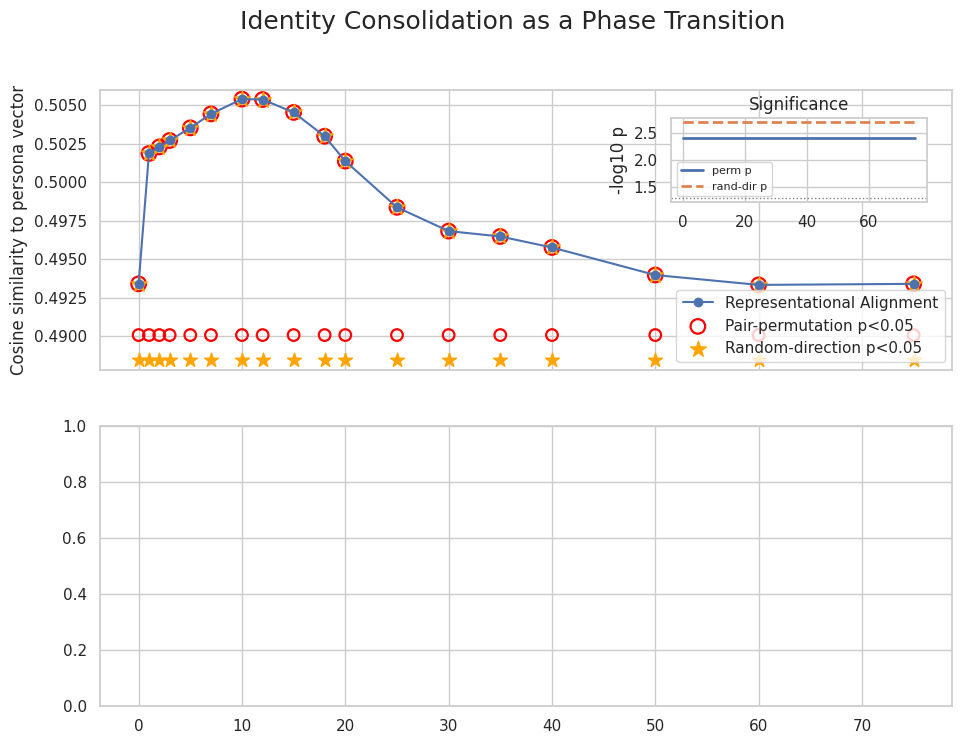

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

base = pd.read_csv("../results/phase_transition_run04.csv")
sig  = pd.read_csv("../results/phase_transition_run04_small_significance.csv")

# Keep just the p-values we need
sig_keep = sig[["checkpoint_step", "perm_p", "randnull_p", "randnull_z"]]
merged = base.merge(sig_keep, on="checkpoint_step", how="inner")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
fig.suptitle("Identity Consolidation as a Phase Transition", fontsize=18)

# --- Top: representational alignment curve ---
ax1.plot(merged["checkpoint_step"], merged["persona_vector_similarity"],
         marker="o", label="Representational Alignment")
ax1.set_ylabel("Cosine similarity to persona vector")

# Significance markers on the SAME curve
perm_mask  = merged["perm_p"]     < 0.05
rand_mask  = merged["randnull_p"] < 0.05

ax1.scatter(merged.loc[perm_mask, "checkpoint_step"],
            merged.loc[perm_mask, "persona_vector_similarity"],
            s=110, facecolors="none", edgecolors="red", linewidths=1.6,
            label="Pair-permutation p<0.05")

ax1.scatter(merged.loc[rand_mask, "checkpoint_step"],
            merged.loc[rand_mask, "persona_vector_similarity"],
            marker="*", s=140, color="orange",
            label="Random-direction p<0.05")

ax1.legend(loc="lower right")

# after you draw ax1 line
ymin, ymax = ax1.get_ylim()
span = ymax - ymin
y_perm  = ymin - 0.20*span
y_rand  = ymin - 0.32*span

perm_mask = merged["perm_p"] < 0.05
rand_mask = merged["randnull_p"] < 0.05

ax1.scatter(merged.loc[perm_mask, "checkpoint_step"],
            [y_perm]*perm_mask.sum(),
            s=70, facecolors="none", edgecolors="red", linewidths=1.6,
            label="Pair perm p<0.05")

ax1.scatter(merged.loc[rand_mask, "checkpoint_step"],
            [y_rand]*rand_mask.sum(),
            marker="*", s=110, color="orange",
            label="Random-dir p<0.05")

# extend axes to show rugs
ax1.set_ylim(y_rand - 0.05*span, ymax)

ax3 = ax1.inset_axes([0.67, 0.60, 0.30, 0.30])  # small inset; or make a 3rd row
ax3.plot(merged["checkpoint_step"], -np.log10(merged["perm_p"]), label="perm p", lw=2)
ax3.plot(merged["checkpoint_step"], -np.log10(merged["randnull_p"]), label="rand-dir p", lw=2, ls="--")
ax3.axhline(-np.log10(0.05), color="gray", lw=1, ls=":")
ax3.set_ylabel("-log10 p"); ax3.set_title("Significance")
ax3.legend(fontsize=8)

delta = merged[["checkpoint_step","persona_vector_similarity","persona_logprob_margin","refusal_elasticity"]].copy()
for col in ["persona_vector_similarity","persona_logprob_margin","refusal_elasticity"]:
    delta[col + "_delta"] = delta[col].diff()

delta_top = delta.sort_values("persona_vector_similarity_delta", ascending=False).head(8)
display(delta_top)


In [70]:
delta = merged[["checkpoint_step","persona_vector_similarity","persona_logprob_margin","refusal_elasticity"]].copy()
for col in ["persona_vector_similarity","persona_logprob_margin","refusal_elasticity"]:
    delta[col + "_delta"] = delta[col].diff()

delta_top = delta.sort_values("persona_vector_similarity_delta", ascending=False).head(8)
display(delta_top)


,checkpoint_step,persona_vector_similarity,persona_logprob_margin,refusal_elasticity,persona_vector_similarity_delta,persona_logprob_margin_delta,refusal_elasticity_delta
1,1,0.501871,1.321798,49.0,0.008470,-0.274241,2.0
6,10,0.505403,1.286728,55.0,0.000960,-0.014433,3.0
5,7,0.504443,1.301161,52.0,0.000908,-0.009331,2.0
4,5,0.503534,1.310493,50.0,0.000819,-0.007379,1.0
2,2,0.502297,1.319919,49.0,0.000426,-0.001880,0.0
3,3,0.502715,1.317871,49.0,0.000418,-0.002047,0.0
17,75,0.493401,1.596040,47.0,0.000068,0.008191,-1.0
7,12,0.505374,1.283941,54.0,-0.000029,-0.002787,-1.0


In [71]:
delta = merged[["checkpoint_step","persona_vector_similarity","persona_logprob_margin","refusal_elasticity"]].copy()
for col in ["persona_vector_similarity","persona_logprob_margin","refusal_elasticity"]:
    delta[col + "_delta"] = delta[col].diff()

delta_top = delta.sort_values("persona_vector_similarity_delta", ascending=False).head(8)
display(delta_top)

,checkpoint_step,persona_vector_similarity,persona_logprob_margin,refusal_elasticity,persona_vector_similarity_delta,persona_logprob_margin_delta,refusal_elasticity_delta
1,1,0.501871,1.321798,49.0,0.008470,-0.274241,2.0
6,10,0.505403,1.286728,55.0,0.000960,-0.014433,3.0
5,7,0.504443,1.301161,52.0,0.000908,-0.009331,2.0
4,5,0.503534,1.310493,50.0,0.000819,-0.007379,1.0
2,2,0.502297,1.319919,49.0,0.000426,-0.001880,0.0
3,3,0.502715,1.317871,49.0,0.000418,-0.002047,0.0
17,75,0.493401,1.596040,47.0,0.000068,0.008191,-1.0
7,12,0.505374,1.283941,54.0,-0.000029,-0.002787,-1.0


In [72]:
# Inspect columns
print("Sig columns:", list(sig.columns))

# Pick p-value & z-score columns that actually exist
p_candidates = [c for c in sig.columns if c.lower().endswith('_p') or c.lower().startswith('p')]
z_candidates = [c for c in sig.columns if 'z' in c.lower()]
print("Detected p-value cols:", p_candidates)
print("Detected z-score cols:", z_candidates)

# Prefer permutation p; fall back to random-null p
p_col = 'perm_p' if 'perm_p' in sig.columns else ('randnull_p' if 'randnull_p' in sig.columns else None)
z_col = 'randnull_z' if 'randnull_z' in sig.columns else None
assert p_col is not None, "No p-value column found in significance CSV."

# Merge base metrics with significance results
merged = base.merge(sig, on="checkpoint_step", how="inner", suffixes=("", "_sig"))

# Ensure numeric dtype
merged[p_col] = pd.to_numeric(merged[p_col], errors='coerce')

# Plot as before, then overlay significance on the *top* subplot
sig_mask = merged[p_col] < 0.05
ax1.scatter(
    merged.loc[sig_mask, "checkpoint_step"],
    merged.loc[sig_mask, "persona_vector_similarity"],
    marker="*", s=120, facecolors="none", edgecolors="red", linewidths=1.5,
    label=f"Significant ({p_col} < 0.05)"
)
ax1.legend(loc="lower right")


Sig columns: ['checkpoint_step', 'delta_pv_cos', 'randnull_mu', 'randnull_sd', 'randnull_z', 'randnull_p', 'obs_mean_sim', 'perm_p', 'n_pairs', 'rand_trials', 'perm_trials', 'checkpoint_path']
Detected p-value cols: ['randnull_p', 'perm_p', 'perm_trials']
Detected z-score cols: ['randnull_z']
